In [1]:
# This work is done for a management team of a hypothetical school.
# My audience is school management team, which is non-technical, but in executive level.
# They asked me to categorize soft drinks for students.

# Question: On waht basis do you want me to categorize soft drinks?

# The management team answered my question with three groups:
# One group shows drinks with high Protein for students who are active and work-out on regular basis.
# One group shows unhealthy drinks based on Sodium level.
# One group shows drinks based on Calories as unhealth for students with Obesity.

# We are given a table of available soft drinks by school management team.
# I will be doing data cleaning as my first step.
# Then, I sort drinks based on desired values and plot diagrams to introduce top drinks for each category.

In [2]:
# I start the job by importing necessary Python libraries and packages, and then, cleaning the dataset.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
drinks = pd.read_csv('/content/starbucks-menu-nutrition-drinks.csv')

In [6]:
drinks.head(10)

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Ombré Pink Drink,-,-,-,-,-,-
2,Pink Drink,-,-,-,-,-,-
3,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
4,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10
5,Violet Drink,-,-,-,-,-,-
6,Evolution Fresh™ Cold-Pressed Apple Berry Juice,-,-,-,-,-,-
7,Evolution Fresh™ Defense Up,-,-,-,-,-,-
8,Evolution Fresh™ Organic Ginger Limeade,110,0,28,0,0,5
9,Iced Coffee,0,0,0,0,0,0


In [7]:
drinks.shape

(177, 7)

In [8]:
# Let's replace all '-' values with NaN:

drinks_1 = drinks.replace('-',np.nan)

In [9]:
drinks_1.head()

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Ombré Pink Drink,NaN,NaN,NaN,NaN,NaN,NaN
2,Pink Drink,NaN,NaN,NaN,NaN,NaN,NaN
3,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
4,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10


In [10]:
# Let's drop all Null values:

drinks_2 = drinks_1.dropna()

In [11]:
drinks_2.head()

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
3,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
4,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10
8,Evolution Fresh™ Organic Ginger Limeade,110,0,28,0,0,5
9,Iced Coffee,0,0,0,0,0,0


In [12]:
drinks_2.shape

(92, 7)

In [13]:
# Let's label first column as 'Drinks' and then reset index:

drinks_2 = drinks_2.reset_index(drop=True)
drinks_3 = drinks_2.rename(columns={drinks_2.columns[0]: 'Drinks'})

In [14]:
drinks_3.head()

,Drinks,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
2,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10
3,Evolution Fresh™ Organic Ginger Limeade,110,0,28,0,0,5
4,Iced Coffee,0,0,0,0,0,0


In [15]:
drinks_3.shape

(92, 7)

In [16]:
drinks_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Drinks     92 non-null     object
 1   Calories   92 non-null     object
 2   Fat (g)    92 non-null     object
 3   Carb. (g)  92 non-null     object
 4   Fiber (g)  92 non-null     object
 5   Protein    92 non-null     object
 6   Sodium     92 non-null     object
dtypes: object(7)
memory usage: 5.2+ KB


In [17]:
drinks_3[['Calories', 'Fat (g)', 'Carb. (g)', 'Fiber (g)', 'Protein', 'Sodium']] = drinks_3[['Calories', 'Fat (g)', 'Carb. (g)', 'Fiber (g)', 'Protein', 'Sodium']].astype(float)

In [18]:
drinks_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Drinks     92 non-null     object 
 1   Calories   92 non-null     float64
 2   Fat (g)    92 non-null     float64
 3   Carb. (g)  92 non-null     float64
 4   Fiber (g)  92 non-null     float64
 5   Protein    92 non-null     float64
 6   Sodium     92 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.2+ KB


In [19]:
# Let's see how many unique drinks we have on the menu:

drinks_3['Drinks'].unique()

array(['Cool Lime Starbucks Refreshers™ Beverage',
       'Strawberry Acai Starbucks Refreshers™ Beverage',
       'Very Berry Hibiscus Starbucks Refreshers™ Beverage',
       'Evolution Fresh™ Organic Ginger Limeade', 'Iced Coffee',
       'Iced Espresso Classics - Vanilla Latte',
       'Iced Espresso Classics - Caffe Mocha',
       'Iced Espresso Classics - Caramel Macchiato', 'Shaken Sweet Tea',
       'Tazo® Bottled Berry Blossom White', 'Tazo® Bottled Black Mango',
       'Tazo® Bottled Black with Lemon', 'Tazo® Bottled Brambleberry',
       'Tazo® Bottled Giant Peach', 'Tazo® Bottled Iced Passion',
       'Tazo® Bottled Lemon Ginger',
       'Tazo® Bottled Organic Black Lemonade',
       'Tazo® Bottled Organic Iced Black Tea',
       'Tazo® Bottled Organic Iced Green Tea',
       'Tazo® Bottled Plum Pomegranate', 'Tazo® Bottled Tazoberry',
       'Tazo® Bottled White Cranberry', 'Teavana® Shaken Iced Black Tea',
       'Teavana® Shaken Iced Black Tea Lemonade',
       'Teavana® 

In [20]:
drinks_3['Drinks'].nunique()


74

In [21]:
# We can rename our dataframe to df:

df = drinks_3

In [22]:
df.head(10)

,Drinks,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45.0,0.0,11.0,0.0,0.0,10.0
1,Strawberry Acai Starbucks Refreshers™ Beverage,80.0,0.0,18.0,1.0,0.0,10.0
2,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60.0,0.0,14.0,1.0,0.0,10.0
3,Evolution Fresh™ Organic Ginger Limeade,110.0,0.0,28.0,0.0,0.0,5.0
4,Iced Coffee,0.0,0.0,0.0,0.0,0.0,0.0
5,Iced Espresso Classics - Vanilla Latte,130.0,2.5,21.0,0.0,5.0,65.0
6,Iced Espresso Classics - Caffe Mocha,140.0,2.5,23.0,0.0,5.0,90.0
7,Iced Espresso Classics - Caramel Macchiato,130.0,2.5,21.0,0.0,5.0,65.0
8,Shaken Sweet Tea,80.0,0.0,19.0,0.0,0.0,10.0
9,Tazo® Bottled Berry Blossom White,60.0,0.0,15.0,0.0,0.0,10.0


In [23]:
# Let's sort Drinks based on Protein to see which drink is more suitable for students who are active sportsmen:

top_protein = df.sort_values(by='Protein', ascending=False)[['Drinks','Protein']].head(10)
print(top_protein)

                                          Drinks  Protein
35         Starbucks® Doubleshot Protein Vanilla     20.0
90                            Chocolate Smoothie     20.0
34  Starbucks® Doubleshot Protein Dark Chocolate     20.0
91                           Strawberry Smoothie     16.0
84    Cinnamon Dolce Frappuccino® Blended Coffee     15.0
63                                 Hot Chocolate     14.0
83                         White Chocolate Mocha     14.0
65                                   Caffè Latte     13.0
66                                   Caffè Mocha     13.0
71                                    Flat White     12.0


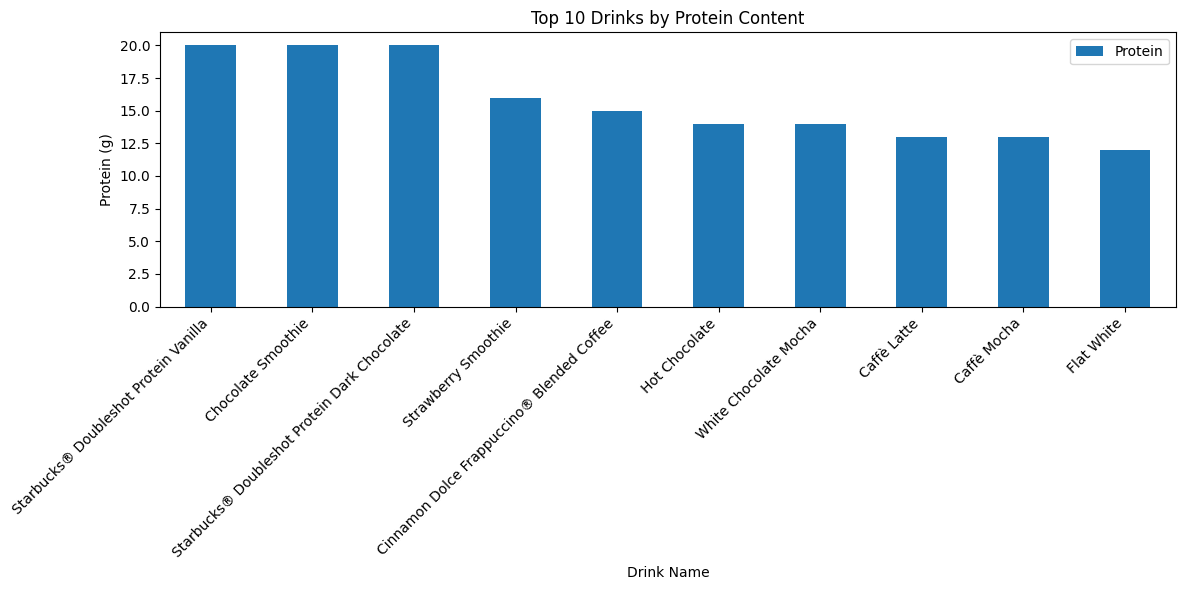

In [24]:
# Let's see Protein drinks on a bar chart:

top_protein.plot.bar(x='Drinks', y='Protein', figsize=(12, 6))
plt.title('Top 10 Drinks by Protein Content')
plt.xlabel('Drink Name')
plt.ylabel('Protein (g)')
plt.xticks(rotation=45 , ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Best protein drinks are named below. Each has 20 grams of Protein.
# 1) Starbucks® Doubleshot Protein Vanilla             20 grams
# 2) Chocolate Smoothie                                20 grams
# 3) Starbucks® Doubleshot Protein Dark Chocolate      20 grams

In [26]:
# Now Let's focus on Sodium. As we know, Sodium is not a desirable material and we generally do not want Sodium to be present in our drinks.
# Let's sort drinks based on level of Sodium and label them as unhealthy drinks:

top_sodium = df.sort_values(by='Sodium', ascending=False)[['Drinks','Sodium']].head(10)
print(top_sodium)


                                      Drinks  Sodium
83                     White Chocolate Mocha   240.0
86         Mocha Frappuccino® Blended Coffee   220.0
85  Coffee Light Frappuccino® Blended Coffee   200.0
78                Iced White Chocolate Mocha   190.0
87   Mocha Light Frappuccino® Blended Coffee   180.0
70               Coconutmilk Mocha Macchiato   180.0
76          Iced Coconutmilk Mocha Macchiato   180.0
65                               Caffè Latte   170.0
90                        Chocolate Smoothie   170.0
71                                Flat White   160.0


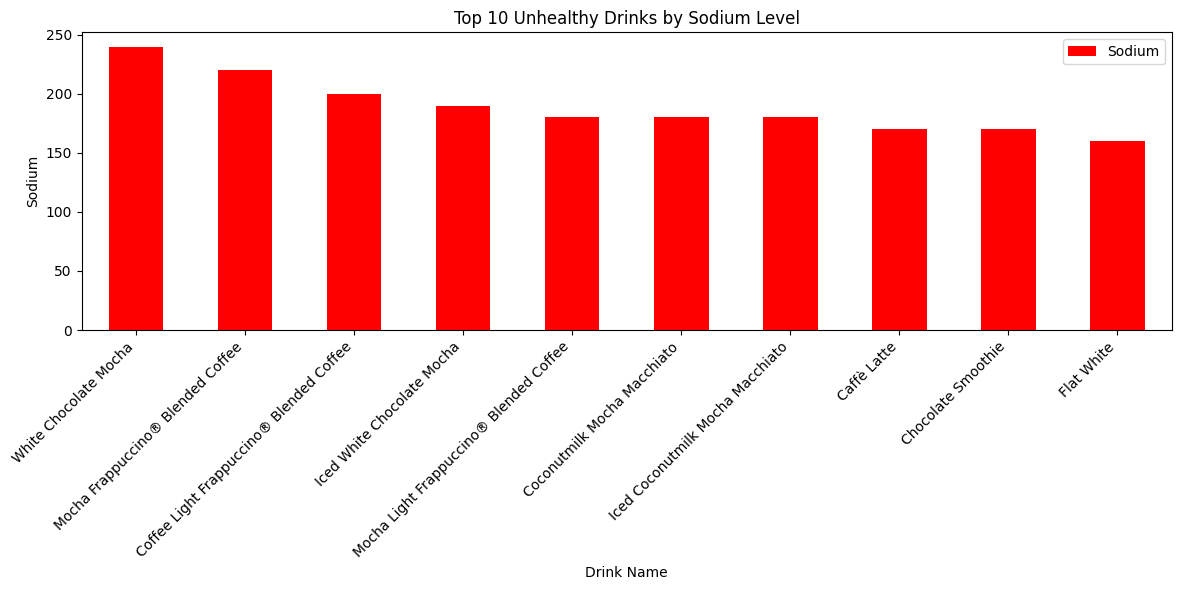

In [27]:
top_sodium.plot.bar(x='Drinks', y='Sodium', figsize=(12, 6), color='red')
plt.title('Top 10 Unhealthy Drinks by Sodium Level')
plt.xlabel('Drink Name')
plt.ylabel('Sodium')
plt.xticks(rotation=45 , ha='right')
plt.tight_layout()
plt.show()

In [28]:
# Top 3 unhealthy drinks by Sodium level are:
# 1) White Chocolate Mocha                        240
# 2) Mocha Frappuccino® Blended Coffee            220
# 3) Coffee Light Frappuccino® Blended Coffee     200


In [29]:
# But as we know, Sodium is not the only unhealthy materials in drinks. High calories can also be harmful.
# Let's sort our drinks based on calories and label them as unhealthy for students with Obisity.

high_calories = df.sort_values(by='Calories', ascending=False)[['Drinks','Calories']].head(10)
print(high_calories)

                                        Drinks  Calories
64          Starbucks® Signature Hot Chocolate     430.0
83                       White Chocolate Mocha     360.0
84  Cinnamon Dolce Frappuccino® Blended Coffee     350.0
63                               Hot Chocolate     320.0
90                          Chocolate Smoothie     320.0
78                  Iced White Chocolate Mocha     300.0
91                         Strawberry Smoothie     300.0
66                                 Caffè Mocha     290.0
86           Mocha Frappuccino® Blended Coffee     280.0
76            Iced Coconutmilk Mocha Macchiato     260.0


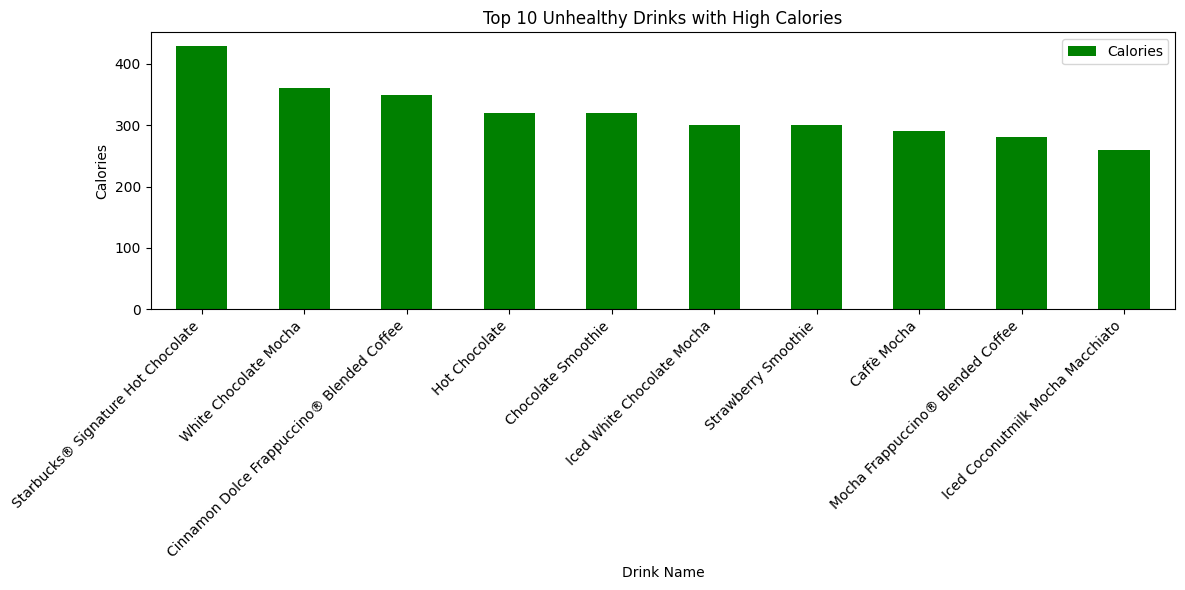

In [42]:
high_calories.plot.bar(x='Drinks', y='Calories', figsize=(12, 6), color='green')
plt.title('Top 10 Unhealthy Drinks with High Calories')
plt.xlabel('Drink Name')
plt.ylabel('Calories')
plt.xticks(rotation=45 , ha='right')
plt.tight_layout()
plt.show()

In [33]:
# These are 3 drinks with highest Calories:
# 1) Starbucks® Signature Hot Chocolate             430
# 2) White Chocolate Mocha                          360
# 3) Cinnamon Dolce Frappuccino® Blended Coffee     350


In [34]:
# Now, as the last step, let's pick top 3 drinks in each category, and compare them against each other.

top_9_drinks = list(high_calories['Drinks'].values[:3]) + list(top_sodium['Drinks'].values[:3]) + list(top_protein['Drinks'].values[:3])
print(top_9_drinks)

['Starbucks® Signature Hot Chocolate', 'White Chocolate Mocha', 'Cinnamon Dolce Frappuccino® Blended Coffee', 'White Chocolate Mocha', 'Mocha Frappuccino® Blended Coffee', 'Coffee Light Frappuccino® Blended Coffee', 'Starbucks® Doubleshot Protein Vanilla', 'Chocolate Smoothie', 'Starbucks® Doubleshot Protein Dark Chocolate']


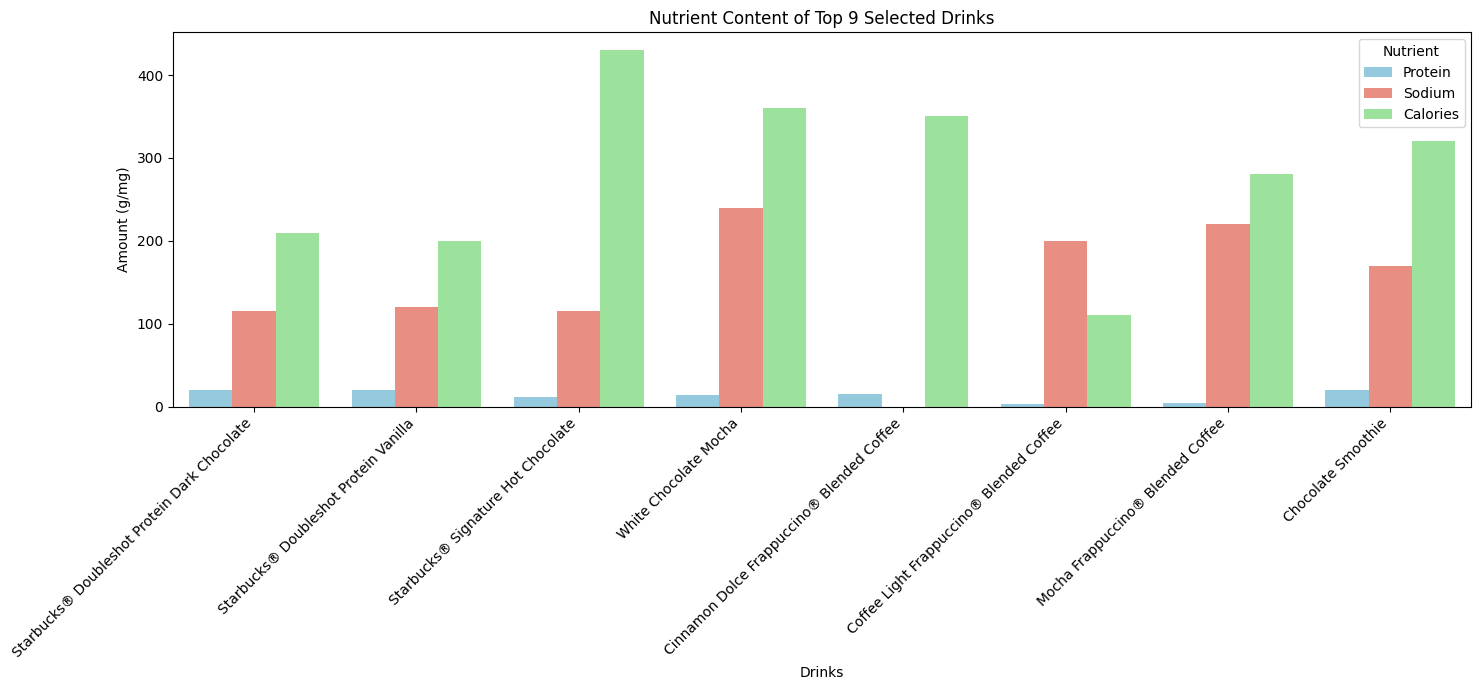

In [35]:
# Ensure top_9_drinks contains unique values if it's derived from multiple lists
unique_top_9_drinks = list(set(top_9_drinks))

# Filter the main DataFrame to get the data for these specific drinks
top_9_df = df[df['Drinks'].isin(unique_top_9_drinks)].copy()

# Melt the DataFrame to prepare for plotting multiple nutrients
melted_df = top_9_df.melt(id_vars=['Drinks'], value_vars=['Protein', 'Sodium', 'Calories'],
                          var_name='Nutrient', value_name='Amount')

plt.figure(figsize=(15, 7))
sns.barplot(
    data=melted_df,
    x='Drinks',
    y='Amount',
    hue='Nutrient',
    palette=['skyblue', 'salmon', 'lightgreen'] # Custom palette for 3 nutrients
)
plt.title('Nutrient Content of Top 9 Selected Drinks')
plt.ylabel('Amount (g/mg)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nutrient')
plt.tight_layout()
plt.show()

In [36]:
# The above diagram shows all top drinks in a single window.
# Students can see this diagram and compare values in order to pick the best drink for themselves.

In [37]:
###########################################################################################################################
###########################################################################################################################
###########################################################################################################################
###########################################################################################################################

In [38]:
###########################################################################################################################

In [39]:
###########################################################################################################################
###########################################################################################################################
###########################################################################################################################
###########################################################################################################################

In [40]:
# The trends I investigated:

# My audience for this project is school management team, which is a non-technical, but in executive level.
# First, I asked for the menu of drinks at the school.
# The school gave me an Excel sheet, including more than 100 of drinks.
# After cleaning the dataset, I made 3 groups.
# One group for Calories, one group for Sodium, and one for Protein.
# Then I picked top 10 drinks per group and plotted a barchart per group.
# The top 3 drinks of each group was selected a sthe next step.
#At the end, I plotted a bar chart including all top drinks from each group and compare them for Protein, Calories, and Sodium.

In [41]:
# The resulting visualizations and conclusions:

# Each student can see the final bar chart and pick the desired drink based on his health condition.
# Drinks with high Sodium and Calories are not healthy, especially for students with Obesity.
# Drinks with high Protein is recommended for students who work out on a regular basis.

##############################################################################################

# Recommendation for the school:

# Unfortunately, none of the drinks on menu are healthy.
# By looking closer to the final bar chart, you can see most of the drinks have high level of Sodium.
# Most of the drinks also have high Calories.
# You can find drinks with lower Calories, but then Protein is not suffiecient for those drinks.
# As final recommendation, the school should add healthier drinks to the coffee shop menu.